### 0 操作前准备

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [6]:
import os
print(os.getcwd())

f:\CTH-MPDSD\Year 2-period 2\ACEX35\Codes\rf_demo\notebooks


In [7]:
ms = pd.read_csv("../data/MS_HEV.csv")
ms.head()
pfloss_ms = pd.read_csv("../data/PFloss_MS.csv")
pfloss_ms.head()

,fid,MS_ID,ARw2kiw,ARw2ktw,ARw2kmw,K4_Upto30k,Per_extent,Tem_extent,ARw500re,ARw2kre,...,PFARw2kiw,PFARw2ktw,PFARw2kmw,PFlossR_2kiw,PFlossR_2ktw,PFlossR_2kmw,N_PFlossR_2kiw,N_PFlossR_2ktw,N_PFlossR_2kmw,Index_acc_loss
0,1,13107,0.0,8.749,1,3,0,0,268,1538,...,0.0,8.749001,1,NaN,1.090038e-07,0.0,NaN,0.0,0.0,0.0
1,2,13108,0.0,8.749,1,3,0,0,268,1304,...,0.0,8.749001,1,NaN,1.090038e-07,0.0,NaN,0.0,0.0,0.0
2,3,13109,0.0,10.467,1,3,0,0,268,1489,...,0.0,10.467000,1,NaN,0.000000e+00,0.0,NaN,0.0,0.0,0.0
3,4,13110,0.0,10.467,1,3,0,0,268,1512,...,0.0,10.467000,1,NaN,0.000000e+00,0.0,NaN,0.0,0.0,0.0
4,5,13111,0.0,8.475,1,3,0,0,268,1508,...,0.0,8.475000,1,NaN,0.000000e+00,0.0,NaN,0.0,0.0,0.0


In [8]:
print(ms.dtypes)

fid                         int64
MS_ID                       int64
ARw2kho                     int64
ARw2kiw                   float64
ARw2ktr                     int64
ARw2ktw                   float64
ARw2klo                     int64
ARw2kmw                     int64
ARw5kho                     int64
ARw5kiw                   float64
ARw5ktr                     int64
ARw5ktw                   float64
ARw5klo                     int64
ARw5kmw                     int64
K4_Upto30k                  int64
Per_extent                  int64
Tem_extent                  int64
ARw500re                    int64
ARw2kre                     int64
ARw500dn                    int64
ARw500rm                    int64
Resident_log              float64
DayNight_log              float64
PRM_log                   float64
Resident_NOR              float64
DayNight_NOR              float64
PRM_NOR                   float64
Street_type_NOR           float64
PF_Index_acc_loss         float64
TF_Index_acc_l

### 1 阈值制定

1.1 检查风险列的基本情况

In [9]:
pf_index_risk_equal = "PF_Index_Risk_equal"   # 改成你的真实列名

print("Column name:", pf_index_risk_equal)
print("Missing values:", ms[pf_index_risk_equal].isna().sum())
print("Min:", ms[pf_index_risk_equal].min())
print("Max:", ms[pf_index_risk_equal].max())
print("Mean:", ms[pf_index_risk_equal].mean())
print("Median:", ms[pf_index_risk_equal].median())

ms[pf_index_risk_equal].describe()

Column name: PF_Index_Risk_equal
Missing values: 12882
Min: 0.0416666666666667
Max: 0.976467984001586
Mean: 0.12735828600993881
Median: 0.125


count    137032.000000
mean          0.127358
std           0.080218
min           0.041667
25%           0.047087
50%           0.125000
75%           0.174018
max           0.976468
Name: PF_Index_Risk_equal, dtype: float64

1.2 可视化risk分布

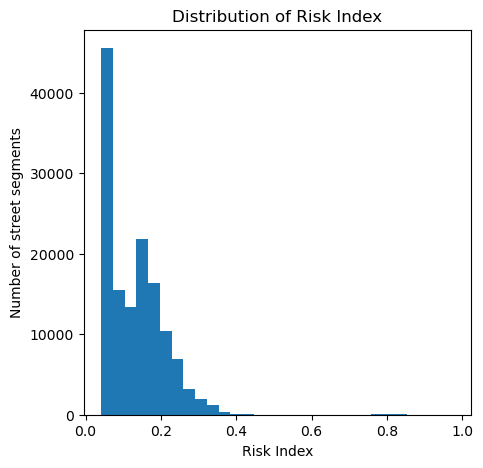

In [36]:
plt.figure(figsize=(5,5))
plt.hist(ms[pf_index_risk_equal].dropna(), bins=30)
plt.xlabel("Risk Index")
plt.ylabel("Number of street segments")
plt.title("Distribution of Risk Index")
plt.show()

1.3 候选阈值样本量比较

In [38]:
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6]

summary = []
total_n = len(ms)

for t in thresholds:
    n = (ms[pf_index_risk_equal] > t).sum()
    pct = n / total_n * 100
    summary.append({
        "threshold": t,
        "count_above_threshold": n,
        "percentage_above_threshold": round(pct, 2)
    })

threshold_summary = pd.DataFrame(summary)
threshold_summary

,threshold,count_above_threshold,percentage_above_threshold
0,0.2,23563,15.72
1,0.3,3003,2.00
2,0.4,370,0.25
3,0.5,265,0.18
4,0.6,223,0.15


In [39]:
ms[pf_index_risk_equal].quantile([0.5, 0.7, 0.8, 0.85, 0.9, 0.95, 0.98, 0.99])

0.50    0.125000
0.70    0.165710
0.80    0.189977
0.85    0.208333
0.90    0.230199
0.95    0.260842
0.98    0.303579
0.99    0.336758
Name: PF_Index_Risk_equal, dtype: float64

In [40]:
thresholds = [0.20, 0.22, 0.24, 0.25, 0.26, 0.28, 0.30]

summary = []
total_n = len(ms)

for t in thresholds:
    n = (ms[pf_index_risk_equal] > t).sum()
    pct = n / total_n * 100
    summary.append({
        "threshold": t,
        "count_above_threshold": n,
        "percentage_above_threshold": round(pct, 2)
    })

threshold_summary = pd.DataFrame(summary)
threshold_summary

,threshold,count_above_threshold,percentage_above_threshold
0,0.20,23563,15.72
1,0.22,16340,10.90
2,0.24,11405,7.61
3,0.25,9207,6.14
4,0.26,7039,4.70
5,0.28,4623,3.08
6,0.30,3003,2.00


### 2 高风险街道的机器学习输入特征表

2.1 融合前检查

In [41]:
print("MS_ID in ms:", "MS_ID" in ms.columns)
print("MS_ID in pfloss_ms:", "MS_ID" in pfloss_ms.columns)

print("fid in ms:", "fid" in ms.columns)
print("fid in pfloss_ms:", "fid" in pfloss_ms.columns)
pf_ms = ms.merge(pfloss_ms, on="MS_ID", how="left")

ms_keys = set(ms["MS_ID"])
acc_keys = set(pfloss_ms["MS_ID"])

print("MS_ID in ms:", len(ms_keys))
print("MS_ID in pfloss_ms:", len(acc_keys))
print("Common MS_ID:", len(ms_keys & acc_keys))
print("Only in ms:", len(ms_keys - acc_keys))
print("Only in pfloss_ms:", len(acc_keys - ms_keys))

MS_ID in ms: True
MS_ID in pfloss_ms: True
fid in ms: True
fid in pfloss_ms: True
MS_ID in ms: 149914
MS_ID in pfloss_ms: 149914
Common MS_ID: 149914
Only in ms: 0
Only in pfloss_ms: 0


In [42]:
acc_cols_needed = [
    "MS_ID",
    "N_PFlossR_2kiw",
    "N_PFlossR_2ktw",
    "N_PFlossR_2kmw"
]

acc_detail_small = pfloss_ms[acc_cols_needed].copy()

pf_ms = ms.merge(acc_detail_small, on="MS_ID", how="left") # MS(pf_ms) UPDATED

print("Original ms shape:", ms.shape)
print("Merged shape:", pf_ms.shape)

new_cols = ["N_PFlossR_2kiw",
    "N_PFlossR_2ktw",
    "N_PFlossR_2kmw"
]
print(pf_ms[new_cols].isna().sum())

pf_ms[["MS_ID"] + new_cols].head()

pf_ms.head()


Original ms shape: (149914, 37)
Merged shape: (149914, 40)
N_PFlossR_2kiw    88125
N_PFlossR_2ktw     5284
N_PFlossR_2kmw    27241
dtype: int64


,fid,MS_ID,ARw2kho,ARw2kiw,ARw2ktr,ARw2ktw,ARw2klo,ARw2kmw,ARw5kho,ARw5kiw,...,Index_population,PF_Index_V_equal,TF_Index_V_equal,TF_Index_V_servicemain,PF_Index_V_servocemain,PF_Index_Risk_equal,TF_Index_Risk_equal,N_PFlossR_2kiw,N_PFlossR_2ktw,N_PFlossR_2kmw
0,13107,13107,0,0.0,6,8.749,1,1,4,95.889999,...,0.454329,0.31811,0.31811,0.238582,0.238582,0.159055,0.159055,NaN,0.0,0.0
1,13108,13108,0,0.0,6,8.749,1,1,4,95.889999,...,0.454329,0.31811,0.31811,0.238582,0.238582,0.159055,0.159055,NaN,0.0,0.0
2,13109,13109,0,0.0,7,10.467,1,1,4,95.889999,...,0.454329,0.31811,0.31811,0.238582,0.238582,0.159055,0.159055,NaN,0.0,0.0
3,13110,13110,0,0.0,7,10.467,1,1,4,95.889999,...,0.454329,0.31811,0.31811,0.238582,0.238582,0.159055,0.159055,NaN,0.0,0.0
4,13111,13111,0,0.0,6,8.475,1,1,4,95.889999,...,0.454329,0.31811,0.31811,0.238582,0.238582,0.159055,0.159055,NaN,0.0,0.0


2.2 固定训练阈值risk index = 0.25并筛选数据集

In [43]:

threshold = 0.25
label_threshold = 0.28    # 用来生成更清晰训练标签的子集
risk_col = "PF_Index_Risk_equal"

high_risk_pf_ms = pf_ms[pf_ms[risk_col] > threshold].copy()

print("Training threshold:", threshold)
print("Number of high-risk MS streets:", len(high_risk_pf_ms))
print("Percentage of all MS streets:", round(len(high_risk_pf_ms) / len(ms) * 100, 2), "%")

high_risk_pf_ms.columns.tolist()
high_risk_pf_ms.dtypes.sort_index()
high_risk_pf_ms.head()

Training threshold: 0.25
Number of high-risk MS streets: 9207
Percentage of all MS streets: 6.14 %


,fid,MS_ID,ARw2kho,ARw2kiw,ARw2ktr,ARw2ktw,ARw2klo,ARw2kmw,ARw5kho,ARw5kiw,...,Index_population,PF_Index_V_equal,TF_Index_V_equal,TF_Index_V_servicemain,PF_Index_V_servocemain,PF_Index_Risk_equal,TF_Index_Risk_equal,N_PFlossR_2kiw,N_PFlossR_2ktw,N_PFlossR_2kmw
77,13184,13184,2,60.0,29,59.234001,271,363,11,355.429993,...,0.502751,0.655280,0.442038,0.349869,0.669732,0.327640,0.221019,-0.833333,-0.730172,-0.575758
78,13185,13185,2,60.0,30,61.324001,272,364,11,355.429993,...,0.502751,0.750917,0.445440,0.354973,0.813188,0.875459,0.222720,-1.000000,-1.000000,-1.000000
79,13186,13186,2,60.0,33,67.096001,276,369,11,355.429993,...,0.508221,0.752740,0.446727,0.355535,0.814555,0.876370,0.223363,-1.000000,-1.000000,-1.000000
80,13187,13187,2,60.0,33,67.096001,286,381,11,355.429993,...,0.533288,0.691741,0.457216,0.365003,0.716790,0.345871,0.228608,-1.000000,-0.648772,-0.727034
81,13188,13188,2,60.0,33,67.096001,288,383,11,355.429993,...,0.533288,0.691899,0.457752,0.365807,0.717027,0.345950,0.228876,-1.000000,-0.648772,-0.728460


In [44]:
meta_cols = [col for col in ["fid", "MS_ID", risk_col] if col in high_risk_pf_ms.columns] # join back to QGIS
meta_pf_ms = high_risk_pf_ms[meta_cols].copy()

meta_pf_ms.head()

,fid,MS_ID,PF_Index_Risk_equal
77,13184,13184,0.327640
78,13185,13185,0.875459
79,13186,13186,0.876370
80,13187,13187,0.345871
81,13188,13188,0.345950


In [45]:
for col in high_risk_pf_ms.columns:
    print(col)

fid
MS_ID
ARw2kho
ARw2kiw
ARw2ktr
ARw2ktw
ARw2klo
ARw2kmw
ARw5kho
ARw5kiw
ARw5ktr
ARw5ktw
ARw5klo
ARw5kmw
K4_Upto30k
Per_extent
Tem_extent
ARw500re
ARw2kre
ARw500dn
ARw500rm
Resident_log
DayNight_log
PRM_log
Resident_NOR
DayNight_NOR
PRM_NOR
Street_type_NOR
PF_Index_acc_loss
TF_Index_acc_loss
Index_population
PF_Index_V_equal
TF_Index_V_equal
TF_Index_V_servicemain
PF_Index_V_servocemain
PF_Index_Risk_equal
TF_Index_Risk_equal
N_PFlossR_2kiw
N_PFlossR_2ktw
N_PFlossR_2kmw


2.3 搭建简化版框架

In [46]:
pf_simple_cols = [
    "Index_population",
    "PF_Index_acc_loss",
    "Street_type_NOR",
    "Per_extent",
]

pf_simple_cols = [col for col in pf_simple_cols if col in high_risk_pf_ms.columns]

print("Simple feature columns:")
print(pf_simple_cols)

X_simple_pf_ms = high_risk_pf_ms[pf_simple_cols].copy()

print("X_simple shape:", X_simple_pf_ms.shape)
X_simple_pf_ms.head()

Simple feature columns:
['Index_population', 'PF_Index_acc_loss', 'Street_type_NOR', 'Per_extent']
X_simple shape: (9207, 4)


,Index_population,PF_Index_acc_loss,Street_type_NOR,Per_extent
77,0.502751,0.713088,0.75,0
78,0.502751,1.000000,0.75,1
79,0.508221,1.000000,0.75,1
80,0.533288,0.791935,0.75,0
81,0.533288,0.792410,0.75,0


In [47]:
print("Missing values in X_simple:")
print(X_simple_pf_ms.isna().sum())

constant_cols_simple_pf_ms = [col for col in X_simple_pf_ms.columns if X_simple_pf_ms[col].nunique() <= 1]
print("Constant columns in X_simple:", constant_cols_simple_pf_ms)

Missing values in X_simple:
Index_population     0
PF_Index_acc_loss    0
Street_type_NOR      0
Per_extent           0
dtype: int64
Constant columns in X_simple: []


In [48]:
X_simple_pf_ms.to_csv("../data/X_simple_pf_ms_0_25.csv", index=False)
meta_pf_ms.to_csv("../data/meta_pf_ms_0_25.csv", index=False)

2.4 搭建细化版框架

In [49]:
population_detail_cols = ["Resident_NOR",
                          "DayNight_NOR", 
                          "PRM_NOR"
]

acc_loss_detail_cols_pf = [
"N_PFlossR_2kiw", 
"N_PFlossR_2ktw", 
"N_PFlossR_2kmw"
]

structure_cols = [
    "Street_type_NOR",
    "Per_extent",
]

structure_cols = [col for col in structure_cols if col in high_risk_pf_ms.columns]
population_detail_cols = [col for col in population_detail_cols if col in high_risk_pf_ms.columns]
acc_loss_detail_cols_pf = [col for col in acc_loss_detail_cols_pf if col in high_risk_pf_ms.columns]

detailed_feature_cols_pf = population_detail_cols + acc_loss_detail_cols_pf + structure_cols

print("Detailed feature columns:")
print(detailed_feature_cols_pf)

X_detailed_pf_ms = high_risk_pf_ms[detailed_feature_cols_pf].copy()

print("X_detailed shape:", X_detailed_pf_ms.shape)
X_detailed_pf_ms.head()

Detailed feature columns:
['Resident_NOR', 'DayNight_NOR', 'PRM_NOR', 'N_PFlossR_2kiw', 'N_PFlossR_2ktw', 'N_PFlossR_2kmw', 'Street_type_NOR', 'Per_extent']
X_detailed shape: (9207, 8)


,Resident_NOR,DayNight_NOR,PRM_NOR,N_PFlossR_2kiw,N_PFlossR_2ktw,N_PFlossR_2kmw,Street_type_NOR,Per_extent
77,0.549144,0.473397,0.485712,-0.833333,-0.730172,-0.575758,0.75,0
78,0.549144,0.473397,0.485712,-1.000000,-1.000000,-1.000000,0.75,1
79,0.565555,0.473397,0.485712,-1.000000,-1.000000,-1.000000,0.75,1
80,0.640754,0.473397,0.485712,-1.000000,-0.648772,-0.727034,0.75,0
81,0.640754,0.473397,0.485712,-1.000000,-0.648772,-0.728460,0.75,0


In [50]:
print("Missing values in X_detailed:")
print(X_detailed_pf_ms.isna().sum().sort_values(ascending=False))

constant_cols_detailed_pf_ms = [col for col in X_detailed_pf_ms.columns if X_detailed_pf_ms[col].nunique() <= 1]
print("Constant columns in X_detailed:", constant_cols_detailed_pf_ms)

Missing values in X_detailed:
N_PFlossR_2kiw     1453
N_PFlossR_2kmw      112
N_PFlossR_2ktw       30
Resident_NOR          0
PRM_NOR               0
DayNight_NOR          0
Street_type_NOR       0
Per_extent            0
dtype: int64
Constant columns in X_detailed: []


In [51]:
# 建0.28

label_pf_ms = pf_ms[pf_ms[risk_col] > label_threshold].copy()

### 3 跑最小样本（简化版）

3.1 分类成因类型

3.1.1 粗暴分位数分类

In [52]:
# 把 4 个核心指标分成 low / medium / high

label_features = [
    "Index_population",
    "Street_type_NOR",
    "PF_Index_acc_loss",
    "Per_extent",
]

def make_level_series(s, force_binary=False):
    if force_binary or set(s.dropna().unique()).issubset({0, 1}):
        return np.where(s > 0, "high", "low")
    
    q1 = s.quantile(0.33)
    q2 = s.quantile(0.66)
    
    return pd.cut(
        s,
        bins=[-np.inf, q1, q2, np.inf],
        labels=["low", "medium", "high"],
        include_lowest=True
    )

high_risk_pf_ms["pop_level"] = make_level_series(high_risk_pf_ms["Index_population"])
high_risk_pf_ms["street_level"] = make_level_series(high_risk_pf_ms["Street_type_NOR"])
high_risk_pf_ms["acc_level"] = make_level_series(high_risk_pf_ms["PF_Index_acc_loss"])
high_risk_pf_ms["exp_level"] = make_level_series(high_risk_pf_ms["Per_extent"], force_binary=True)

In [53]:
# 定义成因标签规则

def assign_cause_label(row):
    # Type B: Flood-exposed streets
    if (row["exp_level"] == "high") and (row["acc_level"] in ["medium", "high"]):
        return "B_flood_exposed"
    
    # Type A: One-and-only streets
    if (
        row["street_level"] == "high"
        and row["pop_level"] in ["medium", "high"]
        and row["acc_level"] in ["medium", "high"]
        and row["exp_level"] in ["low", "medium"]
    ):
        return "A_one_and_only"
    
    # Type C: No-service streets
    if (
        row["acc_level"] == "high"
        and row["street_level"] in ["low", "medium"]
        and row["exp_level"] == "low"
    ):
        return "C_no_service"
    
    return "mixed_review"

high_risk_pf_ms["cause_label"] = high_risk_pf_ms.apply(assign_cause_label, axis=1)

In [54]:
# 映射成 intervention label

cause_to_intervention = {
    "A_one_and_only": 1,   # add street connection
    "B_flood_exposed": 2,  # elevated/protected street
    "C_no_service": 3,     # add emergency service point
    "mixed_review": -1
}

cause_to_intervention_name = {
    "A_one_and_only": "add_street_connection",
    "B_flood_exposed": "elevated_or_protected_street",
    "C_no_service": "add_emergency_service_point",
    "mixed_review": "review"
}

high_risk_pf_ms["intervention_label"] = high_risk_pf_ms["cause_label"].map(cause_to_intervention)
high_risk_pf_ms["intervention_name"] = high_risk_pf_ms["cause_label"].map(cause_to_intervention_name)

In [55]:
# 先看每类样本量

print(high_risk_pf_ms["cause_label"].value_counts(dropna=False))
print()
print((high_risk_pf_ms["cause_label"].value_counts(normalize=True, dropna=False) * 100).round(2))

cause_label
mixed_review       6357
C_no_service       2465
B_flood_exposed     235
A_one_and_only      150
Name: count, dtype: int64

cause_label
mixed_review       69.05
C_no_service       26.77
B_flood_exposed     2.55
A_one_and_only      1.63
Name: proportion, dtype: float64


In [25]:
# 只保留“清晰原型”作为第一版训练集

train_pf_ms = high_risk_pf_ms[high_risk_pf_ms["cause_label"] != "mixed_review"].copy()

print("Training set size:", len(train_pf_ms))
print(train_pf_ms["cause_label"].value_counts())

Training set size: 2850
cause_label
C_no_service       2465
B_flood_exposed     235
A_one_and_only      150
Name: count, dtype: int64


3.1.2 updated

In [56]:
df = high_risk_pf_ms.copy()

# ---------------------------
# 1. 先设几个更有语义的阈值
# ---------------------------
pop_med = df["Index_population"].quantile(0.50)
pop_high = df["Index_population"].quantile(0.66)

acc_med = df["PF_Index_acc_loss"].quantile(0.50)
acc_high = df["PF_Index_acc_loss"].quantile(0.66)

# Street_type_NOR 更建议用语义阈值
street_medhigh = 0.50
street_high = 0.75

# Per_extent
df["is_exposed"] = df["Per_extent"] > 0

print("pop_med, pop_high:", pop_med, pop_high)
print("acc_med, acc_high:", acc_med, acc_high)

# core label_v2

def assign_core_label_v2(row):
    # B: flood-exposed streets
    # 只要有直接暴露，而且acc loss不是特别低，就归B
    if row["is_exposed"] and row["PF_Index_acc_loss"] >= acc_med:
        return "B_flood_exposed"
    
    # A: one-and-only streets
    if (
        row["Street_type_NOR"] >= street_high
        and row["Index_population"] >= pop_med
        and row["PF_Index_acc_loss"] >= acc_med
        and not row["is_exposed"]
    ):
        return "A_one_and_only"
    
    # C: no-service streets
    if (
        row["PF_Index_acc_loss"] >= acc_high
        and row["Street_type_NOR"] < street_high
        and not row["is_exposed"]
    ):
        return "C_no_service"
    
    return "mixed_review"

df["cause_label_core_v2"] = df.apply(assign_core_label_v2, axis=1)

print(df["cause_label_core_v2"].value_counts())
print((df["cause_label_core_v2"].value_counts(normalize=True) * 100).round(2))


pop_med, pop_high: 0.725067318611879 0.763532064502619
acc_med, acc_high: 0.373262373787836 0.5994193417779651
cause_label_core_v2
mixed_review       6636
C_no_service       1816
A_one_and_only      540
B_flood_exposed     215
Name: count, dtype: int64
cause_label_core_v2
mixed_review       72.08
C_no_service       19.72
A_one_and_only      5.87
B_flood_exposed     2.34
Name: proportion, dtype: float64


3.1.3 先判定B再判定AC

In [57]:
def minmax_norm(s):
    s_min = s.min()
    s_max = s.max()
    if s_max == s_min:
        return pd.Series(0.0, index=s.index)
    return (s - s_min) / (s_max - s_min)

df = label_pf_ms.copy()

df["street_n"] = minmax_norm(df["Street_type_NOR"])
df["acc_n"] = minmax_norm(df["PF_Index_acc_loss"])
df["pop_n"] = minmax_norm(df["Index_population"])
df["exp_n"] = df["Per_extent"].astype(int)

df["score_A"] = 0.70 * df["street_n"] + 0.20 * df["pop_n"] + 0.10 * df["acc_n"]
df["score_C"] = 0.70 * df["acc_n"] + 0.20 * df["pop_n"] + 0.10 * (1 - df["street_n"])

def assign_cause_label_v3(row, dominance_margin=0.10, min_strength=0.45):
    # 1. B 优先：只要直接暴露，就先判为 B
    if row["exp_n"] == 1:
        return "B_flood_exposed"
    
    # 2. 非暴露街道：比较 A 和 C 谁更主导
    diff = row["score_A"] - row["score_C"]
    
    if row["score_A"] >= min_strength and diff >= dominance_margin:
        return "A_one_and_only"
    
    if row["score_C"] >= min_strength and diff <= -dominance_margin:
        return "C_no_service"
    
    return "mixed_review"

df["cause_label_v3"] = df.apply(assign_cause_label_v3, axis=1)

print(df["cause_label_v3"].value_counts())
print((df["cause_label_v3"].value_counts(normalize=True) * 100).round(2))

cause_label_v3
A_one_and_only     1938
C_no_service       1524
mixed_review        896
B_flood_exposed     265
Name: count, dtype: int64
cause_label_v3
A_one_and_only     41.92
C_no_service       32.97
mixed_review       19.38
B_flood_exposed     5.73
Name: proportion, dtype: float64


In [58]:
dominance_margin = 0.10
min_strength = 0.45

df["cause_label_v3b"] = df.apply(
    lambda row: assign_cause_label_v3(row, dominance_margin=0.08, min_strength=0.40),
    axis=1
)

print(df["cause_label_v3b"].value_counts())
print((df["cause_label_v3b"].value_counts(normalize=True) * 100).round(2))

cause_label_v3b
A_one_and_only     2121
C_no_service       1691
mixed_review        546
B_flood_exposed     265
Name: count, dtype: int64
cause_label_v3b
A_one_and_only     45.88
C_no_service       36.58
mixed_review       11.81
B_flood_exposed     5.73
Name: proportion, dtype: float64


In [59]:
# 1）把 label 放回高风险样本表
label_cols = ["MS_ID", "cause_label_v3b"]
label_df = df[label_cols].copy()
label_df.head()

# 2）把标签 merge 到高风险样本池
high_risk_labeled_pf_ms = high_risk_pf_ms.merge(label_df, on="MS_ID", how="left")

print(high_risk_labeled_pf_ms.shape)
print(high_risk_labeled_pf_ms["cause_label_v3b"].value_counts(dropna=False))

# 3）先取“明确标签且非 mixed”的训练集
train_pf_ms = high_risk_labeled_pf_ms[
    high_risk_labeled_pf_ms["cause_label_v3b"].notna() &
    (high_risk_labeled_pf_ms["cause_label_v3b"] != "mixed_review")
].copy()

print(train_pf_ms["cause_label_v3b"].value_counts())
print((train_pf_ms["cause_label_v3b"].value_counts(normalize=True) * 100).round(2))


(9207, 48)
cause_label_v3b
NaN                4584
A_one_and_only     2121
C_no_service       1691
mixed_review        546
B_flood_exposed     265
Name: count, dtype: int64
cause_label_v3b
A_one_and_only     2121
C_no_service       1691
B_flood_exposed     265
Name: count, dtype: int64
cause_label_v3b
A_one_and_only     52.02
C_no_service       41.48
B_flood_exposed     6.50
Name: proportion, dtype: float64


In [ ]:
train_pf_ms.head()
train_pf_ms.to_csv("../data/train_pf_ms_0_25.csv", index=False)


In [63]:
print(train_pf_ms.dtypes)

fid                          int64
MS_ID                        int64
ARw2kho                      int64
ARw2kiw                    float64
ARw2ktr                      int64
ARw2ktw                    float64
ARw2klo                      int64
ARw2kmw                      int64
ARw5kho                      int64
ARw5kiw                    float64
ARw5ktr                      int64
ARw5ktw                    float64
ARw5klo                      int64
ARw5kmw                      int64
K4_Upto30k                   int64
Per_extent                   int64
Tem_extent                   int64
ARw500re                     int64
ARw2kre                      int64
ARw500dn                     int64
ARw500rm                     int64
Resident_log               float64
DayNight_log               float64
PRM_log                    float64
Resident_NOR               float64
DayNight_NOR               float64
PRM_NOR                    float64
Street_type_NOR            float64
PF_Index_acc_loss   

In [47]:
# 4）用简化版特征先跑 baseline

simple_feature_cols = [
    "Index_population",
    "PF_Index_acc_loss",
    "Street_type_NOR",
    "Per_extent",
]

X_train_simple_pf_ms = train_pf_ms[simple_feature_cols].copy()
y_train_pf_ms = train_pf_ms["cause_label_v3b"].copy()

print(X_train_simple_pf_ms.shape)
print(y_train_pf_ms.value_counts())


(4077, 4)
cause_label_v3b
A_one_and_only     2121
C_no_service       1691
B_flood_exposed     265
Name: count, dtype: int64


In [48]:
# 5）做训练/测试集划分

from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(
    X_train_simple_pf_ms,
    y_train_pf_ms,
    test_size=0.2,
    random_state=42,
    stratify=y_train_pf_ms
)

print("Train shape:", X_tr.shape)
print("Test shape:", X_te.shape)
print("Train label distribution:")
print(y_tr.value_counts())
print("Test label distribution:")
print(y_te.value_counts())

Train shape: (3261, 4)
Test shape: (816, 4)
Train label distribution:
cause_label_v3b
A_one_and_only     1696
C_no_service       1353
B_flood_exposed     212
Name: count, dtype: int64
Test label distribution:
cause_label_v3b
A_one_and_only     425
C_no_service       338
B_flood_exposed     53
Name: count, dtype: int64


In [51]:
# 6）训练随机森林 baseline

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced_subsample"
)

rf_model.fit(X_tr, y_tr)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [52]:
# 7）评估结果

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = rf_model.predict(X_te)

print("Accuracy:", accuracy_score(y_te, y_pred))
print()
print("Classification report:")
print(classification_report(y_te, y_pred))
print()
print("Confusion matrix:")
print(confusion_matrix(y_te, y_pred))

Accuracy: 1.0

Classification report:
                 precision    recall  f1-score   support

 A_one_and_only       1.00      1.00      1.00       425
B_flood_exposed       1.00      1.00      1.00        53
   C_no_service       1.00      1.00      1.00       338

       accuracy                           1.00       816
      macro avg       1.00      1.00      1.00       816
   weighted avg       1.00      1.00      1.00       816


Confusion matrix:
[[425   0   0]
 [  0  53   0]
 [  0   0 338]]


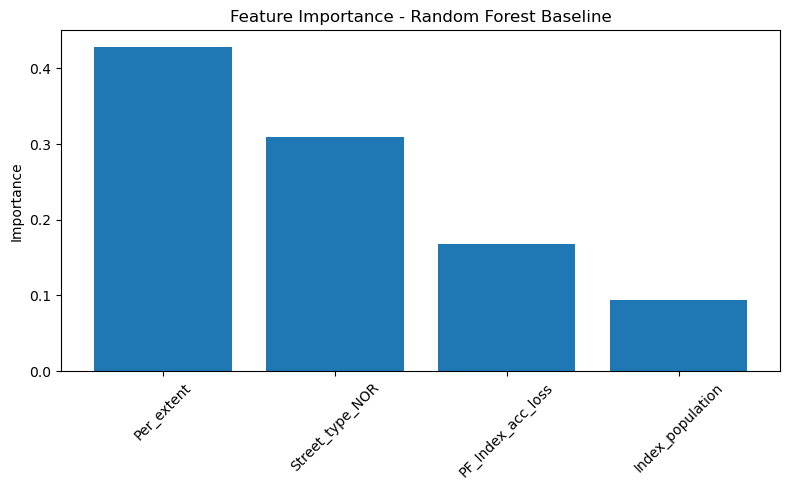

In [49]:
# 8）看特征重要性

feature_importance = pd.DataFrame({
    "feature": X_train_simple_pf_ms.columns,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(feature_importance["feature"], feature_importance["importance"])
plt.xticks(rotation=45)
plt.ylabel("Importance")
plt.title("Feature Importance - Random Forest Baseline")
plt.tight_layout()
plt.show()

1. Use PF_Index_Risk_equal > 0.25 to identify the high-risk street pool.
2. Use a stricter subset to generate clearer rule-based causal labels.
3. Exclude ambiguous mixed_review samples in the first supervised learning baseline.
4. Train a random forest classifier on simplified HEV-related indicators.
5. Predict the dominant intervention type for the broader high-risk street set.

3.2 映射到intervention